In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import duckdb
import seaborn as sns
font_scale = 7
sns.set_theme(style='whitegrid', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import polars as pl
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from great_tables import GT

from conf import conf
from dafm import plots

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [5]:
dataset_cols = ''.join(map(str.strip, """
    id,
    dataset_name,
    dataset_name_latex_short,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
""".splitlines()))

##### Generative method comparison tuning

In [197]:
topk_hyperparameter_filename = 'topk_hyperparameters'
dataset_rows = duckdb.sql(f"""
    select {dataset_cols} from paper_lorenz96
    union
    select {dataset_cols} from paper_kuramoto_sivashinsky
--  union
--  select {dataset_cols} from paper_navier_stokes_dim_64
    union
    select {dataset_cols} from paper_navier_stokes_dim_256
""")
dataset_multiple = 3
assert len(dataset_rows) == dataset_multiple
sampling_time_step_counts = duckdb.sql("select * from sweep_sampling_time_step_count")

##### Classical comparison tuning

In [102]:
topk_hyperparameter_filename = 'topk_hyperparameters_classical_comparison'
dataset_rows = duckdb.sql(f"""
    select {dataset_cols} from paper_kuramoto_sivashinsky_classical_comparison where state_dimension = 512
    union
    select {dataset_cols} from paper_navier_stokes_classical_comparison where state_dimension = 3*64*64
""")
dataset_multiple = 2
assert len(dataset_rows) == dataset_multiple
sampling_time_step_counts = duckdb.sql("select 100")

### Models

In [13]:
model_cols = ''.join(map(str.strip, """
    id,
    model_name,
    hyperparameter1,
    hyperparameter1_name,
    hyperparameter1_name_latex,
    hyperparameter2,
    hyperparameter2_name,
    hyperparameter2_name_latex,
""".splitlines()))

##### Generative method comparison tuning

In [27]:
model_rows = duckdb.sql(rf"""
    select * from (
        select {model_cols} sampling_time_step_count
        from ensf
        where true
        and epsilon_alpha in (select * from sweep_ensf_epsilon_alpha)
        and epsilon_beta in (select * from sweep_ensf_epsilon_beta)
        union
        select {model_cols} sampling_time_step_count
        from enff_ot
        where true
        and sigma_min in (select * from sweep_enff_sigma_min)
        and lambda in (select * from sweep_enff_lambda)
        union
        select {model_cols} sampling_time_step_count
        from enff_f2p
        where true
        and sigma_min in (select * from sweep_enff_sigma_min)
        and lambda in (select * from sweep_enff_lambda)
    )
    where sampling_time_step_count in (select * from sampling_time_step_counts)
""")
model_multiple = sum(
    q.fetchall()[0][0]
    for q in (
        duckdb.sql("select count(*) from sweep_ensf_epsilon_alpha cross join sweep_ensf_epsilon_beta"),
        duckdb.sql("select count(*) from sweep_enff_sigma_min cross join sweep_enff_lambda"),
        duckdb.sql("select count(*) from sweep_enff_sigma_min cross join sweep_enff_lambda"),
    )
)
sampling_time_step_count_multiple = duckdb.sql('select count(*) from sampling_time_step_counts').fetchall()[0][0]

##### Classical comparison tuning

In [28]:
model_classical_rows = duckdb.sql(rf"""
    select {model_cols} null as sampling_time_step_count
    from bpf
    where true
    and inflation in (select * from sweep_classical_inflation)
    union
    select {model_cols} null as sampling_time_step_count
    from enkf_po
    where true
    and inflation in (select * from sweep_classical_inflation)
    and localization in (select * from sweep_classical_localization)
    union
    select {model_cols} null as sampling_time_step_count
    from ienkf_po
    where true
    and inflation in (select * from sweep_classical_inflation)
    union
    select {model_cols} null as sampling_time_step_count
    from esrf
    where true
    and inflation in (select * from sweep_classical_inflation)
    and localization in (select * from sweep_classical_localization)
    union
    select {model_cols} null as sampling_time_step_count
    from letkf
    where true
    and inflation in (select * from sweep_classical_inflation)
    and localization in (select * from sweep_classical_localization)
""")
model_classical_multiple = sum(
    q.fetchall()[0][0]
    for q in (
        duckdb.sql("select count(*) from sweep_classical_inflation"),
        duckdb.sql("select count(*) from sweep_classical_inflation cross join sweep_classical_localization"),
        duckdb.sql("select count(*) from sweep_classical_inflation"),
        duckdb.sql("select count(*) from sweep_classical_inflation cross join sweep_classical_localization"),
        duckdb.sql("select count(*) from sweep_classical_inflation cross join sweep_classical_localization"),
    )
)
sampling_time_step_count_classical_multiple = 1

### General

In [29]:
rows = duckdb.sql("""
    select alt_id, rng_seed, dataset_rows.*, all_model_rows.*
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join (
        select * from model_rows
        union
        select * from model_classical_rows
    ) as all_model_rows on Conf.Model = all_model_rows.id
    where true
    and rng_seed in (select * from rng_seed_train)
""")
multiple = (
    dataset_multiple
    * duckdb.sql("select count(*) from rng_seed_train").fetchall()[0][0]
    * (
        model_multiple * sampling_time_step_count_multiple
        + model_classical_multiple * sampling_time_step_count_classical_multiple
    )
)
assert len(rows) == multiple, f'{len(rows) = } != {multiple}'

In [30]:
duckdb.sql("""
    select
        dataset_name,
        model_name,
        sampling_time_step_count,
        count(*) as num_rows,
    from rows
    group by
        dataset_name,
        model_name,
        sampling_time_step_count,
    having (
        true
      --model_name = 'EnSF' and num_rows = 10 * 8
      --or
      --model_name != 'EnSF' and num_rows <= 13 * 5
    )
    order by dataset_name, model_name desc, sampling_time_step_count
""")

┌─────────────────────┬────────────┬──────────────────────────┬──────────┐
│    dataset_name     │ model_name │ sampling_time_step_count │ num_rows │
│       varchar       │  varchar   │          int64           │  int64   │
├─────────────────────┼────────────┼──────────────────────────┼──────────┤
│ KuramotoSivashinsky │ iEnKF-PO   │                     NULL │       11 │
│ KuramotoSivashinsky │ LETKF      │                     NULL │       88 │
│ KuramotoSivashinsky │ EnSF       │                      100 │       80 │
│ KuramotoSivashinsky │ EnKF-PO    │                     NULL │       88 │
│ KuramotoSivashinsky │ EnFF-OT    │                      100 │       65 │
│ KuramotoSivashinsky │ EnFF-F2P   │                      100 │       65 │
│ KuramotoSivashinsky │ ESRF       │                     NULL │       88 │
│ KuramotoSivashinsky │ BPF        │                     NULL │       11 │
│ NavierStokes        │ iEnKF-PO   │                     NULL │       11 │
│ NavierStokes        │ L

In [31]:
logged_metrics_file_paths = plots.get_logged_metrics_file_paths(rows)
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(path) from logged_metrics_file_paths where exists
)
""")

In [32]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""")
logged_metrics.show(max_width=125)

┌──────────┬────────────┬───────┬──────────────┬───┬───────┬─────────────────────┬────────────────────┬─────────────────────┐
│  alt_id  │  rng_seed  │  id   │ dataset_name │ … │ step  │       time_s        │        crps        │        rmse         │
│ varchar  │   int64    │ int64 │   varchar    │   │ int64 │       double        │       double       │       double        │
├──────────┼────────────┼───────┼──────────────┼───┼───────┼─────────────────────┼────────────────────┼─────────────────────┤
│ 3e29661c │ 2376999025 │    14 │ NavierStokes │ … │  1501 │ 0.20544896399999857 │  16.30998420715332 │ 0.14984309673309326 │
│ 3e29661c │ 2376999025 │    14 │ NavierStokes │ … │  1511 │ 0.24133294699998942 │  16.25271987915039 │ 0.15003518760204315 │
│ 3e29661c │ 2376999025 │    14 │ NavierStokes │ … │  1521 │  0.2360282060000003 │  16.25752830505371 │ 0.15011753141880035 │
│ 3e29661c │ 2376999025 │    14 │ NavierStokes │ … │  1531 │ 0.22206720999999163 │ 16.125375747680664 │ 0.149613022804

In [33]:
duckdb.sql("""
select distinct dataset_name from logged_metrics
""")

┌─────────────────────┐
│    dataset_name     │
│       varchar       │
├─────────────────────┤
│ NavierStokes        │
│ KuramotoSivashinsky │
└─────────────────────┘

In [34]:
required_observation_step_count = duckdb.sql(f"""
    select
        dataset_name,
        max(observation_step_count) as required_observation_step_count,
    from (
        select
            dataset_name,
            count(*) as observation_step_count,
        from logged_metrics
        group by alt_id, dataset_name
    )
    group by dataset_name
""")
required_observation_step_count

┌─────────────────────┬─────────────────────────────────┐
│    dataset_name     │ required_observation_step_count │
│       varchar       │              int64              │
├─────────────────────┼─────────────────────────────────┤
│ KuramotoSivashinsky │                              50 │
│ NavierStokes        │                              50 │
└─────────────────────┴─────────────────────────────────┘

In [35]:
duckdb.sql("""
    select
        dataset_name,
        model_name,
        count(*) as observation_step_count,
    from logged_metrics
    where dataset_name = 'NavierStokes'
    group by alt_id, dataset_name, model_name
    order by observation_step_count
""")

┌──────────────┬────────────┬────────────────────────┐
│ dataset_name │ model_name │ observation_step_count │
│   varchar    │  varchar   │         int64          │
├──────────────┼────────────┼────────────────────────┤
│ NavierStokes │ EnFF-F2P   │                     50 │
│ NavierStokes │ EnFF-OT    │                     50 │
│ NavierStokes │ EnFF-F2P   │                     50 │
│ NavierStokes │ EnSF       │                     50 │
│ NavierStokes │ EnSF       │                     50 │
│ NavierStokes │ EnKF-PO    │                     50 │
│ NavierStokes │ EnKF-PO    │                     50 │
│ NavierStokes │ EnKF-PO    │                     50 │
│ NavierStokes │ EnKF-PO    │                     50 │
│ NavierStokes │ EnKF-PO    │                     50 │
│      ·       │    ·       │                      · │
│      ·       │    ·       │                      · │
│      ·       │    ·       │                      · │
│ NavierStokes │ EnFF-F2P   │                     50 │
│ NavierSt

In [36]:
failed_before_finish_cols = """
    alt_id,
    dataset_name,
    model_name,
"""
failed_before_finish = duckdb.sql(f"""
    select
        observation_steps_back.*,
    from (
        select
            {failed_before_finish_cols}
            count(*) as observation_step_count,
        from logged_metrics
        group by {failed_before_finish_cols}
    ) as observation_steps_back
    join required_observation_step_count
    on observation_steps_back.dataset_name = required_observation_step_count.dataset_name
    and observation_steps_back.observation_step_count < required_observation_step_count.required_observation_step_count
    order by observation_steps_back.dataset_name, model_name desc, observation_step_count
""")
failed_before_finish

┌─────────┬──────────────┬────────────┬────────────────────────┐
│ alt_id  │ dataset_name │ model_name │ observation_step_count │
│ varchar │   varchar    │  varchar   │         int64          │
├─────────┴──────────────┴────────────┴────────────────────────┤
│                            0 rows                            │
└──────────────────────────────────────────────────────────────┘

In [41]:
logged_metrics = duckdb.sql("""
    select
        *
    from logged_metrics
    where alt_id not in (select alt_id from failed_before_finish)
""").pl()

In [42]:
duckdb.sql("""
    select
        dataset_name,
        model_name,
        sampling_time_step_count,
        count(*) as 'Num. runs failed',
    from rows
    where alt_id not in (select alt_id from logged_metrics)
    group by dataset_name, model_name, sampling_time_step_count
    order by dataset_name, model_name, sampling_time_step_count
""")

┌──────────────┬────────────┬──────────────────────────┬──────────────────┐
│ dataset_name │ model_name │ sampling_time_step_count │ Num. runs failed │
│   varchar    │  varchar   │          int64           │      int64       │
├──────────────┼────────────┼──────────────────────────┼──────────────────┤
│ NavierStokes │ EnFF-F2P   │                      100 │                5 │
│ NavierStokes │ EnFF-OT    │                      100 │               16 │
└──────────────┴────────────┴──────────────────────────┴──────────────────┘

### Top-k hyperparameters

In [44]:
group_by = """
    dataset_name,
    dataset_name_latex_short,
    model_name,
    sampling_time_step_count,
    hyperparameter1,
    hyperparameter1_name,
    hyperparameter1_name_latex,
    hyperparameter2,
    hyperparameter2_name,
    hyperparameter2_name_latex,
"""
logged_metrics_means = duckdb.sql(f"""
    select
        {group_by}
        mean(time_s) as time_s_mean,
        mean(rmse) as rmse,
        mean(crps) as crps,
    from logged_metrics
    group by
        {group_by}
""")
logged_metrics_means.show(max_width=125)

┌─────────────────────┬──────────────────────┬───┬──────────────────────┬──────────────────────┬────────────────────┐
│    dataset_name     │ dataset_name_latex…  │ … │     time_s_mean      │         rmse         │        crps        │
│       varchar       │       varchar        │   │        double        │        double        │       double       │
├─────────────────────┼──────────────────────┼───┼──────────────────────┼──────────────────────┼────────────────────┤
│ NavierStokes        │ NS                   │ … │   0.2953290125800001 │  0.13302361339330673 │ 10.712662315368652 │
│ KuramotoSivashinsky │ KS                   │ … │  0.0029970009399997… │   1.7448187208027597 │  39.21178036850538 │
│ KuramotoSivashinsky │ KS                   │ … │  0.23373812120000195 │  0.16251499403251507 │ 3.6073293210243604 │
│ NavierStokes        │ NS                   │ … │   38.414397760120025 │  0.07319686606526375 │  6.466233463287353 │
│ NavierStokes        │ NS                   │ … │  0.29

In [76]:
ranked_by_rmse = duckdb.sql(f"""
    select
        *,
        row_number() over (
            partition by dataset_name, model_name, sampling_time_step_count, k
            order by k
        ) as tie_breaker
    from (
        select
            dataset_name,
            dataset_name_latex_short,
            model_name,
            sampling_time_step_count,
            hyperparameter1,
            hyperparameter1_name,
            hyperparameter1_name_latex,
            hyperparameter2,
            hyperparameter2_name,
            hyperparameter2_name_latex,
            rmse,
            crps,
            time_s_mean,
            dense_rank() over (
                partition by dataset_name, model_name, sampling_time_step_count
                order by rmse
            ) as k,
        from logged_metrics_means
    )
    order by dataset_name, model_name, sampling_time_step_count, k, tie_breaker
""")
ranked_by_rmse.show(max_width=125)

┌─────────────────────┬──────────────────────┬────────────┬───┬──────────────────────┬───────┬─────────────┐
│    dataset_name     │ dataset_name_latex…  │ model_name │ … │     time_s_mean      │   k   │ tie_breaker │
│       varchar       │       varchar        │  varchar   │   │        double        │ int64 │    int64    │
├─────────────────────┼──────────────────────┼────────────┼───┼──────────────────────┼───────┼─────────────┤
│ KuramotoSivashinsky │ KS                   │ BPF        │ … │  0.0027413442799998… │     1 │           1 │
│ KuramotoSivashinsky │ KS                   │ BPF        │ … │  0.0029950533800000… │     1 │           2 │
│ KuramotoSivashinsky │ KS                   │ BPF        │ … │ 0.004100662539999717 │     1 │           3 │
│ KuramotoSivashinsky │ KS                   │ BPF        │ … │ 0.002788947179999539 │     2 │           1 │
│ KuramotoSivashinsky │ KS                   │ BPF        │ … │  0.0037634790799996… │     3 │           1 │
│ KuramotoSivashins

In [103]:
duckdb.sql(f"""
    copy (
        select
            dataset_name,
            model_name,
            sampling_time_step_count,
            hyperparameter1,
            hyperparameter1_name,
            hyperparameter2,
            hyperparameter2_name,
            rmse,
            crps,
            time_s_mean,
            k,
            tie_breaker,
        from ranked_by_rmse
    ) to '../sweeps/{topk_hyperparameter_filename}.csv'
""")

In [96]:
top1_hyperparameters = duckdb.sql("""
    select
        dataset_name,
        dataset_name_latex_short as System,
        model_name,
        sampling_time_step_count as '$T$',
        hyperparameter1,
        hyperparameter1_name_latex,
        hyperparameter2,
        hyperparameter2_name_latex,
    from ranked_by_rmse
    where true
    and k = 1 and tie_breaker = 1
    and (
      true
      --dataset_name != 'NavierStokesDim256' and sampling_time_step_count = 5
      --or
      --dataset_name = 'NavierStokesDim256' and sampling_time_step_count = 10
    )
    order by sampling_time_step_count, dataset_name, model_name desc
""").pl()
top1_hyperparameters

dataset_name,System,model_name,$T$,hyperparameter1,hyperparameter1_name_latex,hyperparameter2,hyperparameter2_name_latex
str,str,str,i64,f64,str,f64,str
"""KuramotoSivashinsky""","""KS""","""EnSF""",100,1.0,"""$\epsilon_{\alpha}$""",0.005,"""$\epsilon_{\beta}$"""
"""KuramotoSivashinsky""","""KS""","""EnFF-OT""",100,0.001,"""$\sigma_{\min}$""",0.4,"""$\lambda$"""
"""KuramotoSivashinsky""","""KS""","""EnFF-F2P""",100,0.01,"""$\sigma_{\min}$""",0.005,"""$\lambda$"""
"""NavierStokes""","""NS""","""EnSF""",100,1.0,"""$\epsilon_{\alpha}$""",0.005,"""$\epsilon_{\beta}$"""
"""NavierStokes""","""NS""","""EnFF-OT""",100,0.00001,"""$\sigma_{\min}$""",0.2,"""$\lambda$"""
…,…,…,…,…,…,…,…
"""NavierStokes""","""NS""","""iEnKF-PO""",null,1.5,"""Inflation""",null,"""Localization"""
"""NavierStokes""","""NS""","""LETKF""",null,1.0,"""Inflation""",1.0,"""Localization"""
"""NavierStokes""","""NS""","""EnKF-PO""",null,1.1,"""Inflation""",8.0,"""Localization"""


In [99]:
top1_hyperparameters_pivot = top1_hyperparameters.pivot(
    on=['model_name', 'hyperparameter1_name_latex', 'hyperparameter2_name_latex'],
    index=['System'],
    values=['hyperparameter1', 'hyperparameter2'],
    separator='|',
)
cols = ['System']
gt = GT(top1_hyperparameters_pivot)
gt = gt.tab_spanner(label=' ', columns=['System'])
for model_name, hyperparameter1_name_latex, hyperparameter2_name_latex in (
    top1_hyperparameters[['model_name', 'hyperparameter1_name_latex', 'hyperparameter2_name_latex']].unique().iter_rows()
):
    value_string = f'{{"{model_name}","{hyperparameter1_name_latex}","{hyperparameter2_name_latex}"}}'
    cols = {
        f'hyperparameter1|{value_string}': hyperparameter1_name_latex,
        f'hyperparameter2|{value_string}': hyperparameter2_name_latex
    }
    gt = gt.tab_spanner(label=model_name, columns=list(cols)).cols_label(**cols)
    if 'sigma' in hyperparameter1_name_latex:
        gt = gt.fmt_scientific(columns=list(cols)[0], decimals=0)
gt

GT(_tbl_data=shape: (2, 17)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ System ┆ hyperparam ┆ hyperparam ┆ hyperpara ┆ … ┆ hyperpara ┆ hyperpara ┆ hyperpara ┆ hyperpara │
│ ---    ┆ eter1|{"En ┆ eter1|{"En ┆ meter1|{" ┆   ┆ meter2|{" ┆ meter2|{" ┆ meter2|{" ┆ meter2|{" │
│ str    ┆ SF","$\eps ┆ FF-OT","$\ ┆ EnFF-F2P" ┆   ┆ LETKF","I ┆ EnKF-PO", ┆ ESRF","In ┆ BPF","Inf │
│        ┆ …          ┆ …          ┆ ,"$…      ┆   ┆ nfl…      ┆ "In…      ┆ fla…      ┆ lat…      │
│        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│        ┆ f64        ┆ f64        ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ KS     ┆ 1.0        ┆ 0.001      ┆ 0.01      ┆ … ┆ 8.0       ┆ 8.0       ┆ 7.0       ┆ null      │
│ NS     ┆ 1.0        ┆ 0.00001    ┆ 0.001     ┆ … ┆ 1.0       ┆ 8.0       ┆ 6.0       ┆ null      │
└────────┴────────────┴────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7b3ade549240>, _boxhead=Boxhead([ColInfo(var='System', type=<ColInfoTypeEnum.default: 1>, column_label='System', column_align='left', column_width=None), ColInfo(var='hyperparameter1|{"EnSF","$\\epsilon_{\\alpha}$","$\\epsilon_{\\beta}$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\epsilon_{\\alpha}$', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"EnSF","$\\epsilon_{\\alpha}$","$\\epsilon_{\\beta}$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\epsilon_{\\beta}$', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"EnFF-OT","$\\sigma_{\\min}$","$\\lambda$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\sigma_{\\min}$', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"EnFF-OT","$\\sigma_{\\min}$","$\\lambda$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\lambda$', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"EnFF-F2P","$\\sigma_{\\min}$","$\\lambda$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\sigma_{\\min}$', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"EnFF-F2P","$\\sigma_{\\min}$","$\\lambda$"}', type=<ColInfoTypeEnum.default: 1>, column_label='$\\lambda$', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"iEnKF-PO","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Inflation', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"iEnKF-PO","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Localization', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"LETKF","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Inflation', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"LETKF","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Localization', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"EnKF-PO","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Inflation', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"EnKF-PO","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Localization', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"ESRF","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Inflation', column_align='right', column_width=None), ColInfo(var='hyperparameter2|{"ESRF","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Localization', column_align='right', column_width=None), ColInfo(var='hyperparameter1|{"BPF","Inflation","Localization"}', type=<ColInfoTypeEnum.default: 1>, column_label='Inflation', column

In [94]:
table_latex = (
    gt.as_latex()
    .replace(r'\{', r'{')
    .replace(r'\}', r'}')
    .replace(r'\_', r'_')
    .replace(r'\$', r'$')
    .replace(r'\\times', r'\times')
    .replace(r'\\epsilon', r'\varepsilon')
    .replace(r'\\alpha', r'\alpha')
    .replace(r'\\beta', r'\beta')
    .replace(r'\\sigma', r'\sigma')
    .replace(r'\\min', r'\min')
    .replace(r'\\lambda', r'\lambda')
    .replace('None', '--')
    .replace('Inflation', 'Infl.')
    .replace('Localization', 'Loc.')
)
for i in range(1, 4):
    table_latex = table_latex.replace(rf'1 $\times$ 10\textsuperscript{{-{i}}}', f'0.{"":{0}<{i-1}}1')
table_latex = table_latex.replace(r'1 $\times$ ', '')
print(table_latex)

\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lrrrrrrrrrrrrrrrr}
\toprule
\multicolumn{1}{c}{ } & \multicolumn{2}{c}{EnSF} & \multicolumn{2}{c}{EnFF-OT} & \multicolumn{2}{c}{EnFF-F2P} & \multicolumn{2}{c}{iEnKF-PO} & \multicolumn{2}{c}{LETKF} & \multicolumn{2}{c}{EnKF-PO} & \multicolumn{2}{c}{ESRF} & \multicolumn{2}{c}{BPF} \\ 
\cmidrule(lr){1-1} \cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11} \cmidrule(lr){12-13} \cmidrule(lr){14-15} \cmidrule(lr){16-17}
System & $\varepsilon_{\alpha}$ & $\varepsilon_{\beta}$ & $\sigma_{\min}$ & $\lambda$ & $\sigma_{\min}$ & $\lambda$ & Infl. & Loc. & Infl. & Loc. & Infl. & Loc. & Infl. & Loc. & Infl. & Loc. \\ 
\midrule\addlinespace[2.5pt]
KS & 1.0 & 0.005 & 0.001 & 0.4 & 0.01 & 0.005 & 1.8 & -- & 1.0 & 8.0 & 1.0 & 8.0 & 1.4 & 7.0 & 1.7 & -- \\
NS & 1.0 & 0.005 & 10\textsuperscript{-5} & 0.2 & 0.001 & 0.005 & 1.5 & -- & 1.0 & 1.0 & 1.1 & 8.

### Heatmap

In [115]:
hyperparameter_grid = duckdb.sql("""
    select
        'EnSF' as model_name,
        epsilon_alpha as hyperparameter1,
        epsilon_beta as hyperparameter2,
    from sweep_ensf_epsilon_alpha
    cross join sweep_ensf_epsilon_beta
    union
    select
        model_name,
        sigma_min as hyperparameter1,
        lambda as hyperparameter2,
    from sweep_enff_sigma_min
    cross join sweep_enff_lambda
    cross join (values ('EnFF-OT'), ('EnFF-F2P')) as t(model_name)
""")

In [119]:
grid_search_info = duckdb.sql("""
    select distinct
        dataset_name,
        model_name,
        sampling_time_step_count,
        hyperparameter1_name_latex,
        hyperparameter2_name_latex,
    from rows
    order by dataset_name, model_name desc, sampling_time_step_count
""")
grid_search_info

┌─────────────────────┬────────────┬──────────────────────────┬────────────────────────────┬────────────────────────────┐
│    dataset_name     │ model_name │ sampling_time_step_count │ hyperparameter1_name_latex │ hyperparameter2_name_latex │
│       varchar       │  varchar   │          int64           │          varchar           │          varchar           │
├─────────────────────┼────────────┼──────────────────────────┼────────────────────────────┼────────────────────────────┤
│ KuramotoSivashinsky │ EnSF       │                        5 │ $\epsilon_{\alpha}$        │ $\epsilon_{\beta}$         │
│ KuramotoSivashinsky │ EnSF       │                       10 │ $\epsilon_{\alpha}$        │ $\epsilon_{\beta}$         │
│ KuramotoSivashinsky │ EnSF       │                       20 │ $\epsilon_{\alpha}$        │ $\epsilon_{\beta}$         │
│ KuramotoSivashinsky │ EnSF       │                      100 │ $\epsilon_{\alpha}$        │ $\epsilon_{\beta}$         │
│ KuramotoSivashinsky │ 

In [140]:
def get_logged_metrics_pivot_table(
    dataset_name,
    model_name,
    sampling_time_step_count,
    hyperparameter1_name_latex,
    hyperparameter2_name_latex,
):
    logged_metrics_pivot = (
        duckdb.sql(f"""
            select
                hyperparameter_grid_filtered.hyperparameter1,
                hyperparameter_grid_filtered.hyperparameter2,
                rmse,
            from (
                select
                    hyperparameter1,
                    hyperparameter2,
                    rmse,
                from logged_metrics
                where true
                and model_name = {model_name!r}
                and sampling_time_step_count = {sampling_time_step_count}
            ) as logged_metrics_filtered
            right join (
                select
                    *
                from hyperparameter_grid
                where true
                and model_name = {model_name!r}
            ) as hyperparameter_grid_filtered on (
                logged_metrics_filtered.hyperparameter1 = hyperparameter_grid_filtered.hyperparameter1
                and
                logged_metrics_filtered.hyperparameter2 = hyperparameter_grid_filtered.hyperparameter2
            )
            order by hyperparameter_grid_filtered.hyperparameter1, hyperparameter_grid_filtered.hyperparameter2
        """).pl()
        .select('hyperparameter1', 'hyperparameter2', 'rmse')
        .pivot(on='hyperparameter1', index='hyperparameter2', aggregate_function='mean')
        .to_pandas()
        .set_index('hyperparameter2')
    )
    logged_metrics_pivot.index = logged_metrics_pivot.index.rename(hyperparameter2_name_latex)
    if model_name == 'EnSF':
        logged_metrics_pivot.columns = logged_metrics_pivot.columns.rename(hyperparameter1_name_latex)
        logged_metrics_pivot = logged_metrics_pivot.T
    else:
        logged_metrics_pivot.columns = logged_metrics_pivot.columns.map(lambda x: f'{float(x):.0e}').rename(hyperparameter1_name_latex)
    return logged_metrics_pivot

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

$\epsilon_{\beta}$,0.001,0.005,0.025,0.075,0.125,0.175,0.225,0.275
$\epsilon_{\alpha}$,,,,,,,,
0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.596089
0.8,NaN,NaN,NaN,NaN,18.522341,16.990912,15.320230,14.263871
0.9,24.400080,NaN,22.371671,18.828527,16.173224,13.990950,7.113976,6.218357


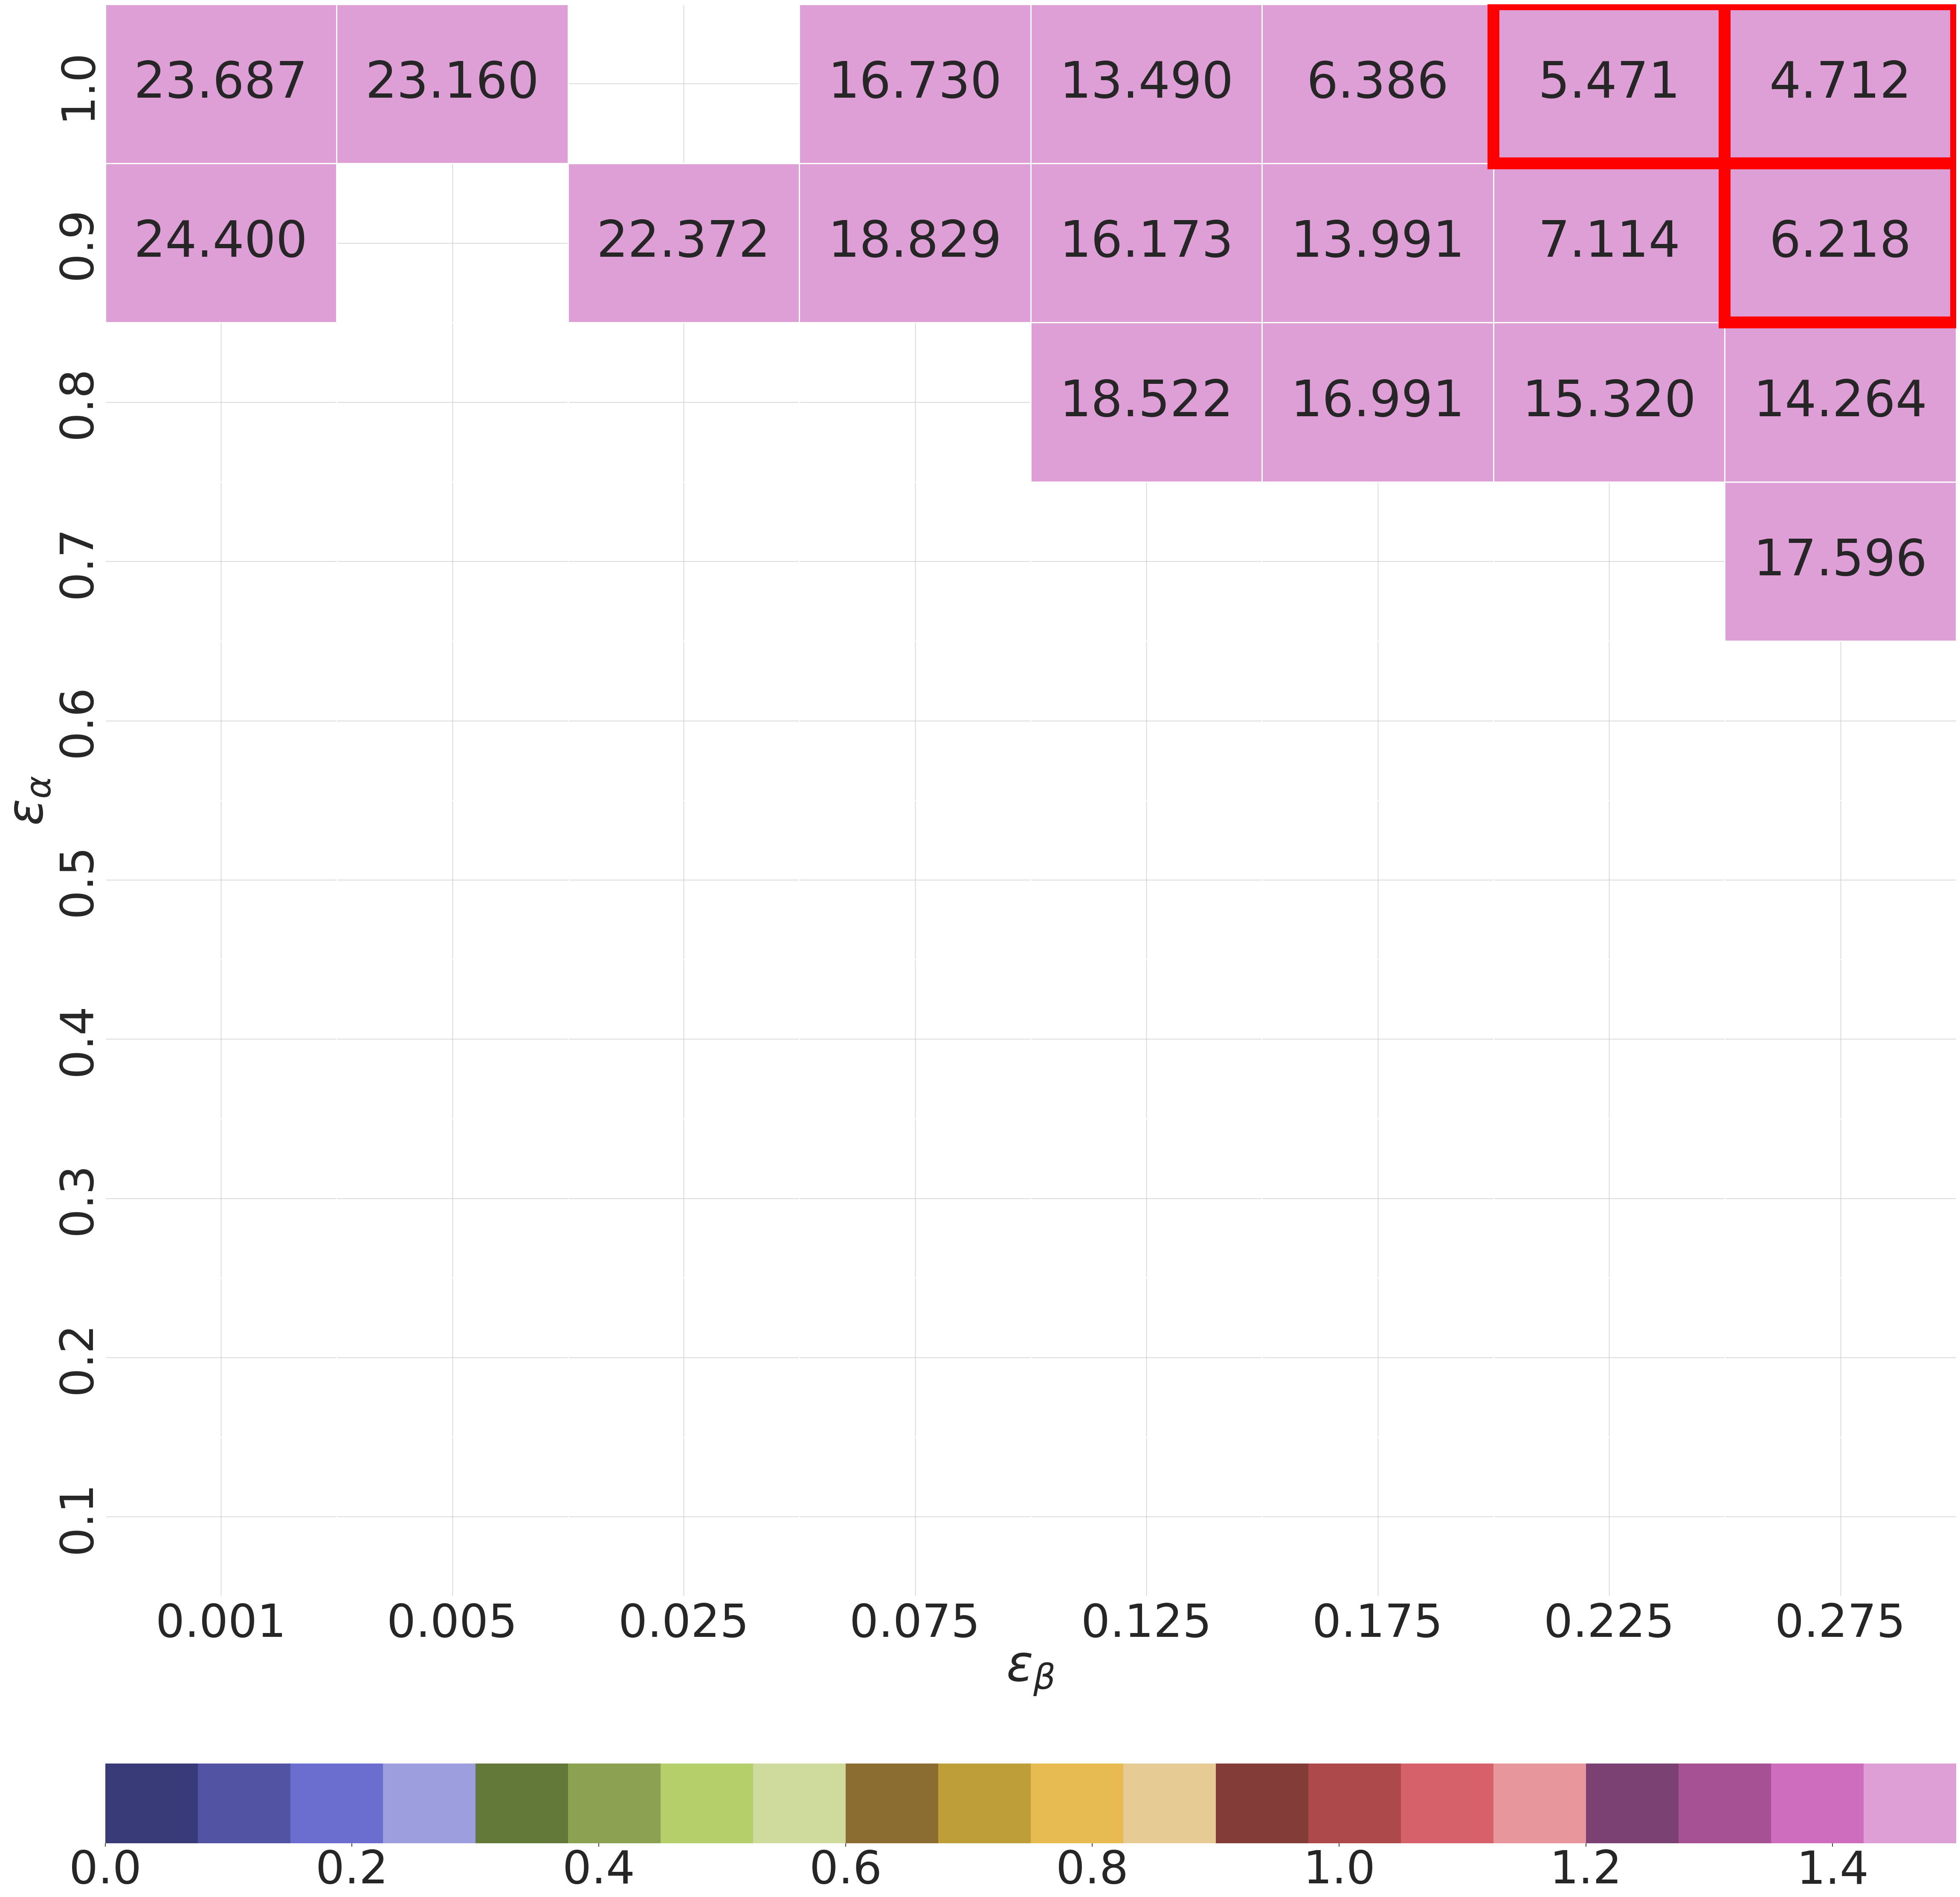

In [141]:
for (
    dataset_name,
    model_name,
    sampling_time_step_count,
    hyperparameter1_name_latex,
    hyperparameter2_name_latex,
) in grid_search_info.fetchall():
    logged_metrics_pivot = get_logged_metrics_pivot_table(
        dataset_name,
        model_name,
        sampling_time_step_count,
        hyperparameter1_name_latex,
        hyperparameter2_name_latex,
    )
    top_idx = list(zip(*np.unravel_index(logged_metrics_pivot.fillna(1e6).to_numpy().ravel().argsort()[:3], logged_metrics_pivot.shape)))
    
    if model_name == 'EnSF':
        wscale = .8 * font_scale#+ 1
        hscale = 1 * font_scale#+ 4
    else:
        wscale = .3 * font_scale
        hscale = 1.7 * font_scale
    fig, (ax, ax_cbar) = plt.subplots(2, 1, height_ratios=[20, 1], figsize=(wscale * logged_metrics_pivot.shape[0], hscale * logged_metrics_pivot.shape[1]))
    # rmse_max = 5
    (
        sns.heatmap(
            data=logged_metrics_pivot,
            linewidths=1,
            annot=True,
            fmt='.3f',
            cmap='tab20b',
            # cmap=cmap,
            vmin=.0,
            vmax=1.5,
            ax=ax,
            cbar_ax=ax_cbar,
            cbar_kws=dict(
                orientation='horizontal',
            ),
        )
    )
    top_idx_rev = [tuple(reversed(idx)) for idx in top_idx]
    for idx in top_idx_rev:
        ax.add_patch(matplotlib.patches.Rectangle(idx, 1, 1, fill=False, edgecolor='red', lw=20))
    # ax_cbar.remove()
    # ax.invert_xaxis()
    ax.invert_yaxis()
    
    file_dir = Path(dataset_name)
    file_dir.mkdir(exist_ok=True)
    fig.savefig(file_dir/f'Tune_{model_name}_T{sampling_time_step_count}.pdf', format='pdf', bbox_inches='tight', pad_inches=.06)
    break
logged_metrics_pivot